In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import ResultLoader, plot_results, plot_loss

# Set plot style
plt.style.use("seaborn-v0_8-whitegrid")

# Increase font sizes for better visibility
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

In [2]:
def load_plot(selected_group, experiments, common_args, loader, x_lim):
    results = {}
    for label in selected_group:
        if label not in experiments: continue
        algo_name, kwargs = experiments[label]
        data = loader.load(algo_name, **{**common_args, **kwargs}, specific_run=0)
        if data: results[label] = data

    if results:
        plot_results(results, x_lim, metric="acc", title=f"Test Accuracy on {common_args['dataset']} ({common_args['partition']})")
        # plot_loss(results, title=f"Training Loss on {common_args['dataset']} ({common_args['partition']})")
    else:
        print("\n[Error] No results loaded. Check the warnings above for path/parameter mismatches.")

def load_plot_all_runs(selected_group, experiments, common_args, loader, x_lim):
    print(f"\nSummary of ALL RUNS (Mean ± Std):")
    header = f"{'Algorithm':<20} | {'Max Acc':>20} | {'Last 10 Avg':>20}"
    print("-" * 70)
    print(header)
    print("-" * 70)

    for label in selected_group:
        if label not in experiments: continue
        algo_name, kwargs = experiments[label]

        merged_args = {**common_args, **kwargs}
        total_times = merged_args.get('times', 1)

        run_results = []
        idx = 0
        while True:
            data = loader.load(algo_name, **merged_args, specific_run=idx)
            if data is None: break
            run_results.append(data)
            idx += 1

        if not run_results: continue

        metrics = ["acc"]
        for metric in metrics:
            sample_data = run_results[0][metric]

            if isinstance(sample_data, list):
                max_accs = []
                last_10_avgs = []
                for run_data in run_results:
                    y = run_data[metric][0:x_lim]
                    if not y: continue
                    max_accs.append(max(y))
                    last_10_avgs.append(np.mean(y[-10:]) if len(y) >= 10 else np.mean(y))

                if not max_accs: continue
                mean_max, std_max = np.mean(max_accs), np.std(max_accs)
                mean_last, std_last = np.mean(last_10_avgs), np.std(last_10_avgs)
                print(f"{label:<20} | {mean_max:>8.4f} ± {std_max:<7.4f} | {mean_last:>8.4f} ± {std_last:<7.4f} ({len(run_results)}/{total_times} runs)")

            elif isinstance(sample_data, dict):
                for key in ["model", "local", "proto", "global"]:
                    if key not in sample_data: continue

                    max_accs = []
                    last_10_avgs = []
                    for run_data in run_results:
                        y = run_data[metric][key][0:x_lim]
                        if not y: continue
                        max_accs.append(max(y))
                        last_10_avgs.append(np.mean(y[-10:]) if len(y) >= 10 else np.mean(y))

                    if not max_accs: continue
                    mean_max, std_max = np.mean(max_accs), np.std(max_accs)
                    mean_last, std_last = np.mean(last_10_avgs), np.std(last_10_avgs)
                    suffix = "Model" if key in ["model", "local"] else "Proto" if key == "proto" else "Global"
                    print(f"{label+'-'+suffix:<20} | {mean_max:>8.4f} ± {std_max:<7.4f} | {mean_last:>8.4f} ± {std_last:<7.4f} ({len(run_results)}/{total_times} runs)")

In [3]:
loader = ResultLoader("../results")
experiments = {
    "FedAvg": ("fedavg", {}),
    "FedProx": ("fedprox", {"mu": 0.01}),
    "Scaffold": ("scaffold", {"global_lr": 1.0}),
    "FedDyn": ("feddyn", {"alpha_coef": 0.1}),
    "FedPLN": ("fedpln", {"lambda_": 10.0, "epoch_pln": 10, "lr_pln": 0.01, "batch_size_pln": 64, "depth_pln": 1, "width_pln": 512, "mode": "normal", "har": 0, "fixed_proto": 0, "init_emb": 0}),
    "FedProc": ("fedproc", {}),
    "FedFM": ("fedfm", {"mu": 1.0}),
    "MOON": ("moon", {"mu": 0.01, "tau": 0.5}),
    "FedSA": ("fedsa", {"alpha_sa": 0.9999, "lambda_r": 0.1, "lambda_mcl": 0.01, "lambda_cc": 1.0}),
    "FedLSA": ("fedlsa", {"lambda_com": 0.1, "alpha_sep": 0.1, "server_epochs": 10, "server_lr": 0.01, "tau": 0.1}),

    "FedPer": ("fedper", {}),
    "FedRep": ("fedrep", {"epochs_head": 5}),
    "FedProto": ("fedproto", {"mu": 1.0}),
    "FedALA": ("fedala", {"eta": 1.0, "rand_percent": 20, "layer_idx": 1, "ala_threshold": 0.1, "num_pre_loss": 10}),
    "FedTGP": ("fedtgp", {"lamda_": 10.0, "server_epochs": 10, "server_lr": 0.01, "margin_threshold": 1.0}),
    "FedDPC": ("feddpc", {"lamda_": 100.0, "head_epochs": 10, "body_epochs": 2, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01, "lambda_p": 1.0, "lambda_acl": 0.01}),
    "LG-FedAvg": ("lgfedavg", {}),
    "FedKD": ("fedkd", {"lr_g": 0.01, "energy": 0.9}),
    "FML": ("fml", {"alpha_fml": 1.0, "beta_fml": 1.0}),
    "ProxyFL": ("proxyfl", {"mu": 1.0, "adj_type": "ring"}),
    "Local": ("local", {}),
}
global_algos = ["FedAvg", "FedProx", "Scaffold", "FedDyn", "FedPLN", "FedProc", "FedFM", "MOON", "FedLSA"]
personalized_algos = ["FedPer", "FedRep", "FedProto", "FedALA", "FedTGP", "FedDPC", "LG-FedAvg", "FedKD", "FML", "ProxyFL", "FedSA", "Local"]

In [9]:
loader.algo_patterns["feddpc"] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}_{args['lambda_p']}_{args['lambda_acl']}"
loader.algo_patterns["feddpc1"] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}_{args['lambda_p']}_{args['lambda_acl']}"

common_args = {"dataset": "cifar100", "partition": "dirichlet", "num_clients": 10, "epochs": 1, "batch_size": 64, "lr": 0.01, "alpha": 0.1, "n_class": 2, "times": 5}

experiments["FedDPC"] = ("feddpc", {"epochs": 1, "lamda_": 100.0, "lambda_p": 1.0, "lambda_acl": 0.01, "head_epochs": 10, "body_epochs": 1, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01})
experiments["FedDPC1"] = ("feddpc1", {"epochs": 1, "lamda_": 100.0, "lambda_p": 1.0, "lambda_acl": 0.01, "head_epochs": 10, "body_epochs": 1, "lr_head": 0.01, "lr_body": 0.01, "margin_threshold": 100.0, "server_epochs": 100, "server_lr": 0.01})

Figure saved to figures/test_accuracy_on_cifar100_dirichlet.png

Summary of ACC:
-----------------------------------------------------------------
Algorithm            |         Max Acc |     Last 10 Avg
-----------------------------------------------------------------
FedProto-Model       |         53.1305 |         52.7281
FedProto-Proto       |         49.4699 |         49.1155
FedTGP-Model         |         55.0394 |         53.8490
FedTGP-Proto         |         54.6851 |         53.7713
FedDPC-Model         |         55.8043 |         54.2833
FedDPC-Proto         |         55.8009 |         54.5685
LG-FedAvg            |         49.0075 |         48.7402
FedKD                |         50.6510 |         49.9527
FML-Model            |         54.4829 |         53.9482
FML-Global           |         33.4000 |         33.1425
ProxyFL-Model        |         53.5381 |         53.0953
FedSA                |         51.3452 |         50.9912
Local                |         48.8253 |      

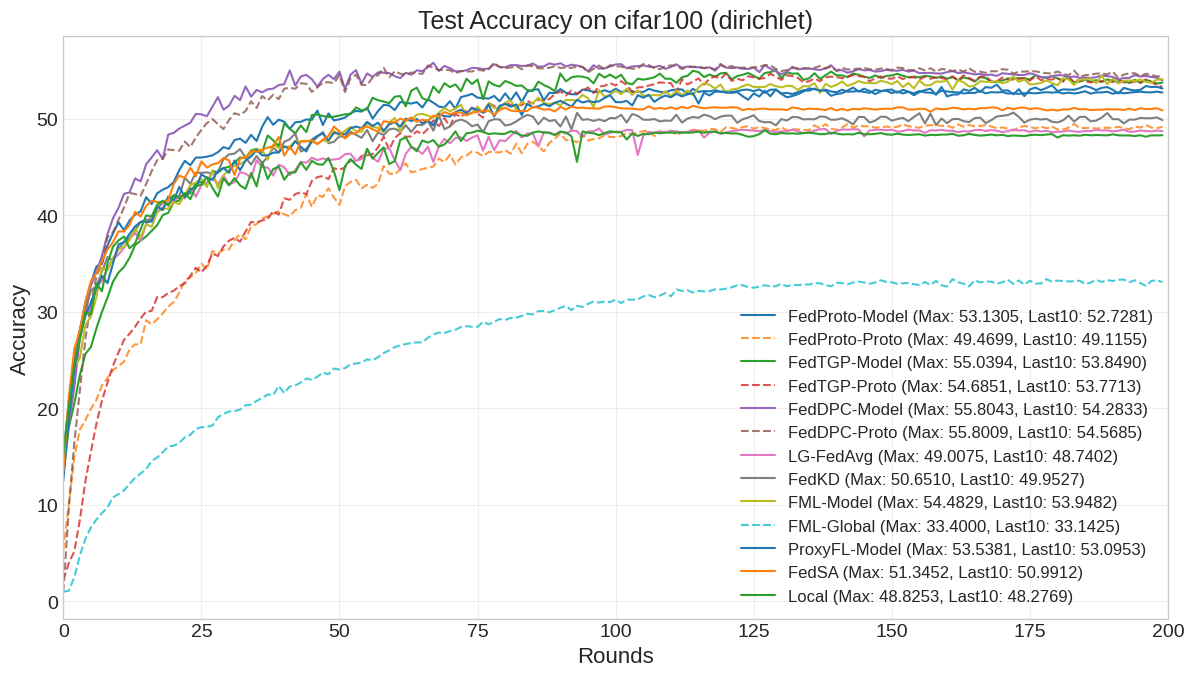

In [10]:
selected_group = personalized_algos.copy()
for algo in ['FedALA', 'FedPer', 'FedRep']:
    if algo in selected_group:
        selected_group.remove(algo)

# selected_group = ['FedTGP', 'FedProto']
selected_group.extend(['FedDPC'])

load_plot(selected_group, experiments, common_args, loader, 200)

In [6]:
print("\n--- Personalized Algorithms Stats ---")
load_plot_all_runs(personalized_algos, experiments, common_args, loader, x_lim=200)
# print("\n--- Global Algorithms Stats ---")
# load_plot_all_runs(global_algos, experiments, common_args, loader, x_lim=200)


--- Personalized Algorithms Stats ---

Summary of ALL RUNS (Mean ± Std):
----------------------------------------------------------------------
Algorithm            |              Max Acc |          Last 10 Avg
----------------------------------------------------------------------


FedPer               |  52.1548 ± 0.7247  |  51.0548 ± 0.6353  (5/5 runs)
FedRep               |  54.1662 ± 0.5547  |  52.5584 ± 0.5428  (5/5 runs)
FedProto-Model       |  53.1285 ± 0.3982  |  52.7082 ± 0.3687  (5/5 runs)
FedProto-Proto       |  49.3738 ± 0.2610  |  49.1036 ± 0.2264  (5/5 runs)
FedALA               |  53.2169 ± 0.3623  |  51.6063 ± 0.5169  (5/5 runs)
FedTGP-Model         |  54.3800 ± 0.3826  |  53.3301 ± 0.3311  (5/5 runs)
FedTGP-Proto         |  54.1989 ± 0.2732  |  53.2783 ± 0.3216  (5/5 runs)
FedDPC-Model         |  55.3743 ± 0.2328  |  53.7489 ± 0.3369  (5/5 runs)
FedDPC-Proto         |  55.5882 ± 0.1463  |  54.3019 ± 0.1464  (5/5 runs)
LG-FedAvg            |  48.3933 ± 0.5110  |  47.9324 ± 0.5862  (5/5 runs)
FedKD                |  50.5788 ± 0.4063  |  49.8385 ± 0.3800  (5/5 runs)
FML-Model            |  54.3404 ± 0.4188  |  53.7790 ± 0.3753  (5/5 runs)
FML-Global           |  33.5450 ± 0.5416  |  33.2170 ± 0.5007  (5/5 runs)
ProxyFL-Model        |  53.2658 ± 0.39